In [1]:
#####Exploratory Data Analysis (EDA):
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
##1.Loading the dataset:
df = pd.read_csv('diabetes (1).csv')


In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.size

6912

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
####2.Checking missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

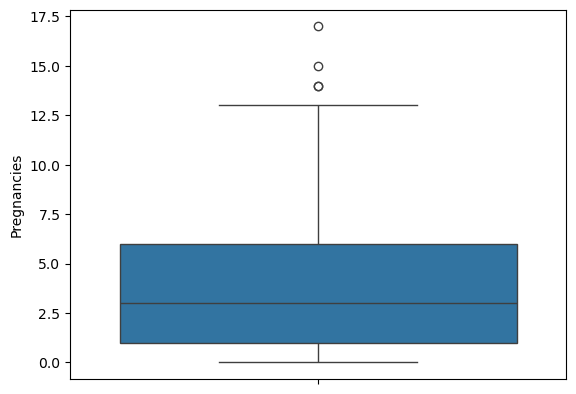

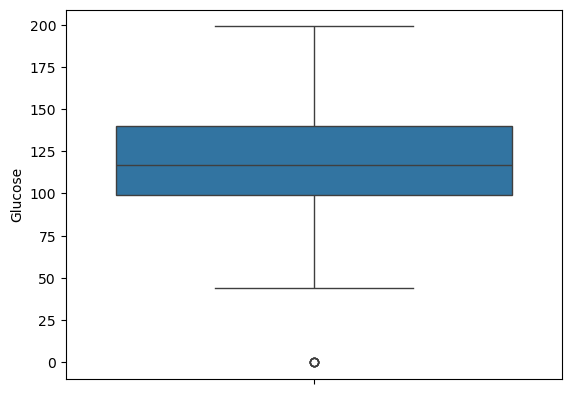

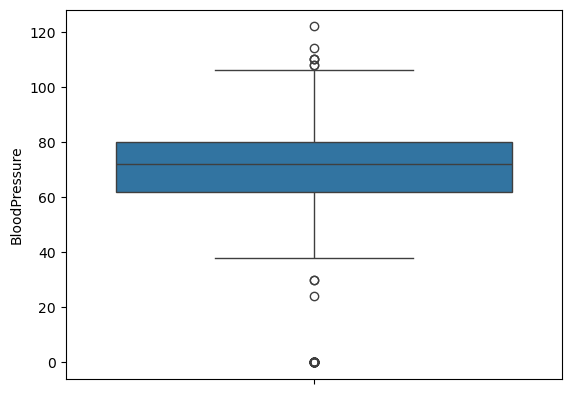

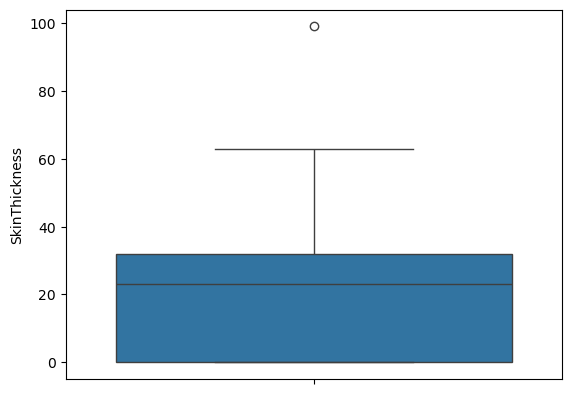

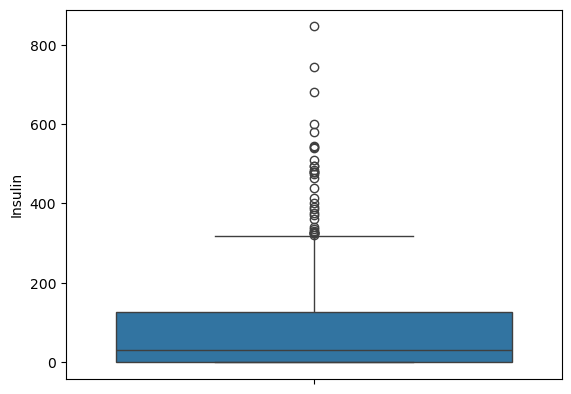

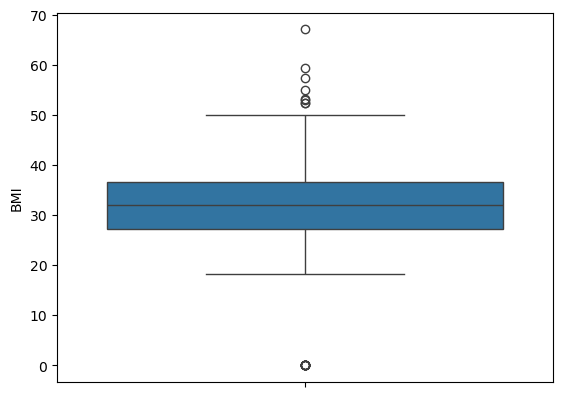

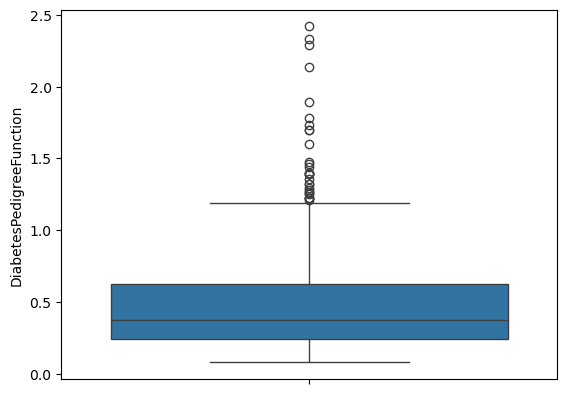

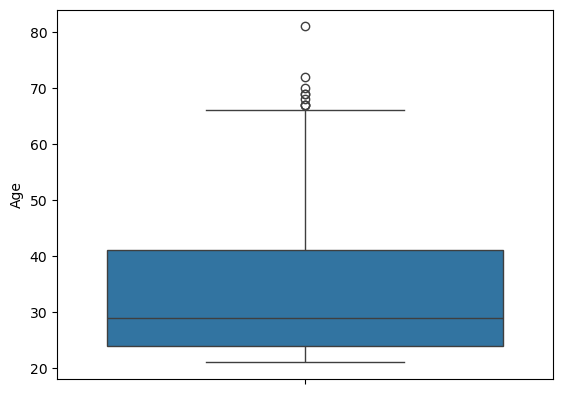

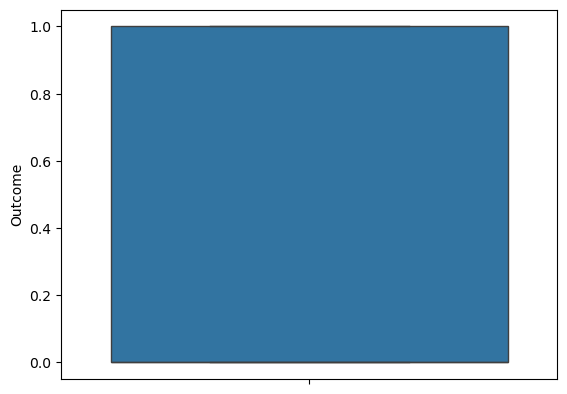

In [10]:
###Checking Outliers:
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [11]:
#Outlier capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

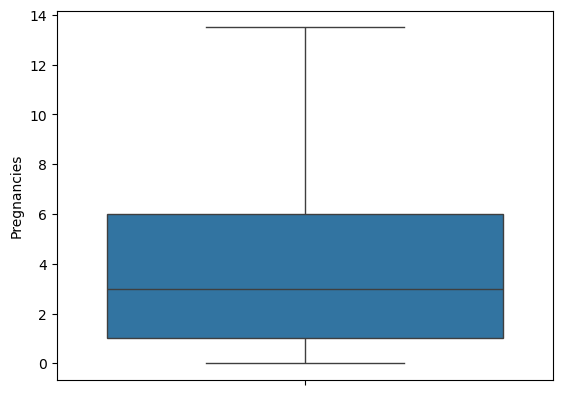

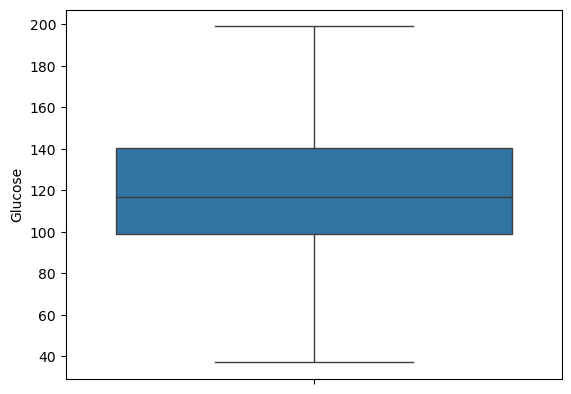

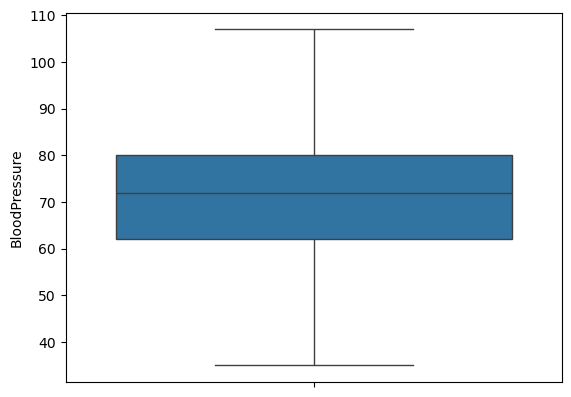

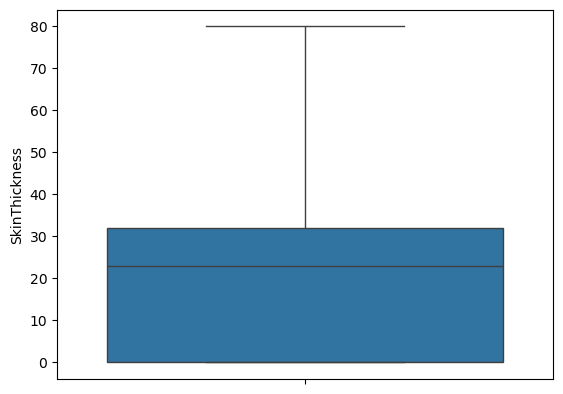

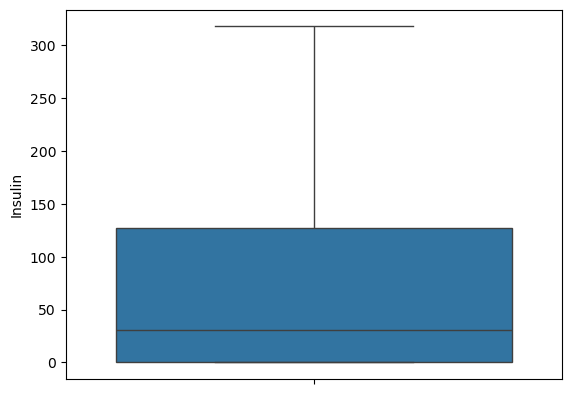

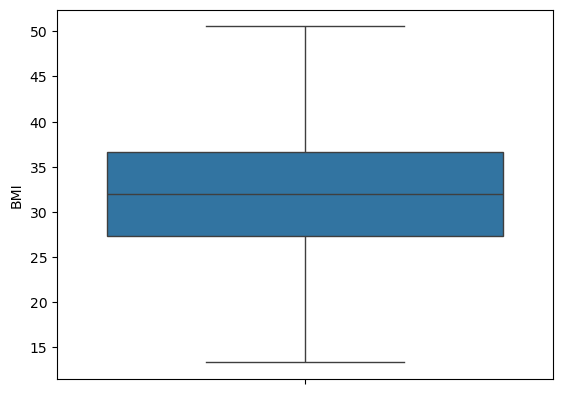

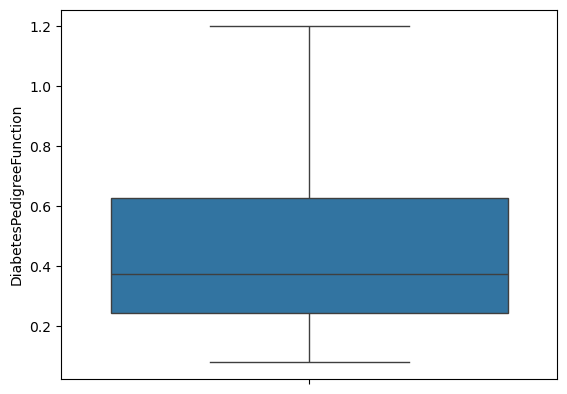

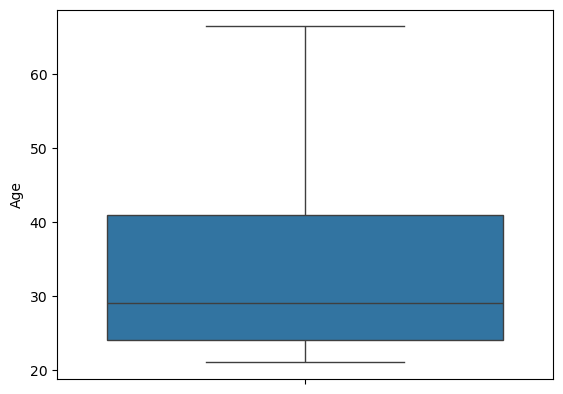

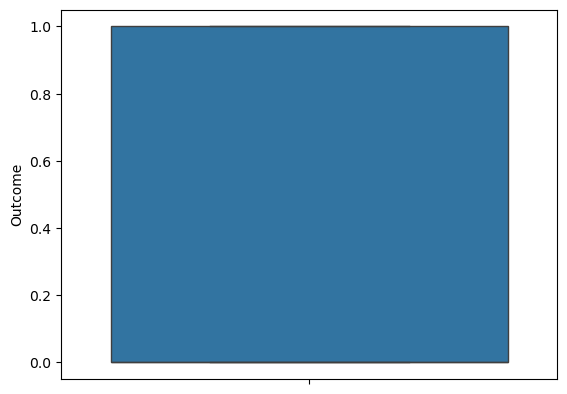

In [12]:
#Checking Outliers again after capping
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [13]:
df.dtypes

Pregnancies                 float64
Glucose                     float64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


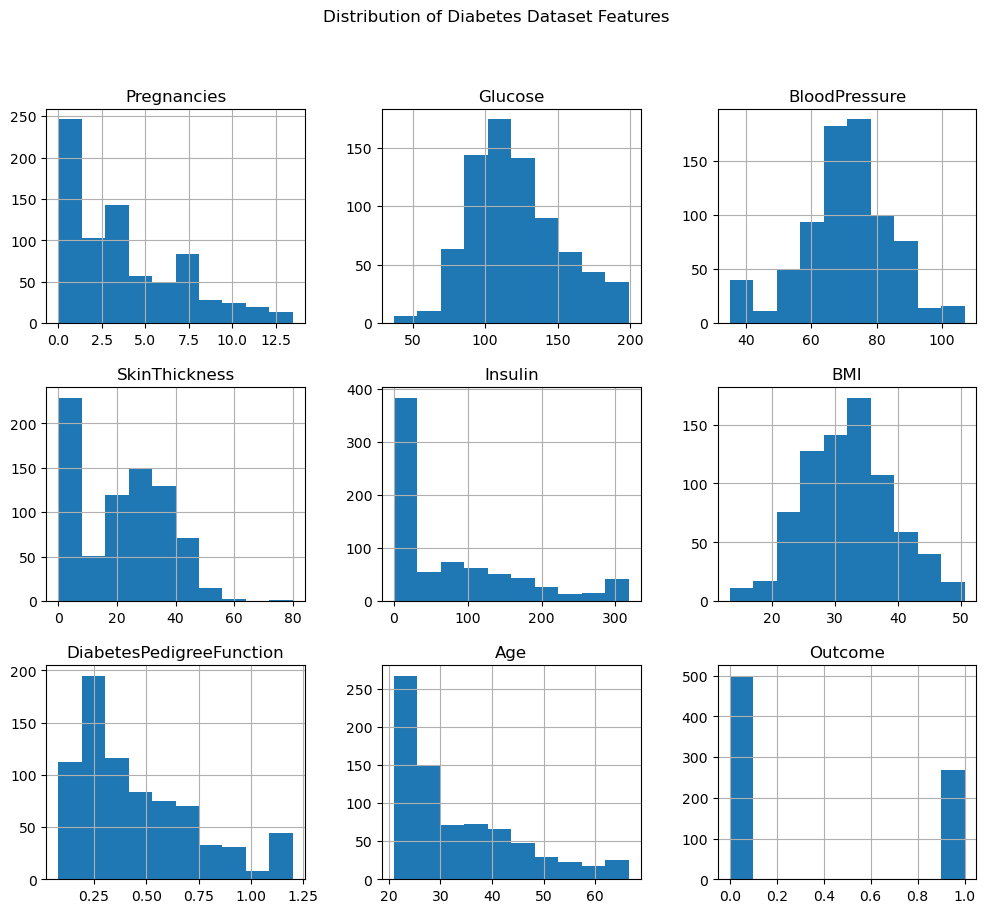

In [15]:
####3.Exploring the data distributions using histograms and box plots:
df.hist(figsize=(12,10))
plt.suptitle('Distribution of Diabetes Dataset Features')
plt.show()

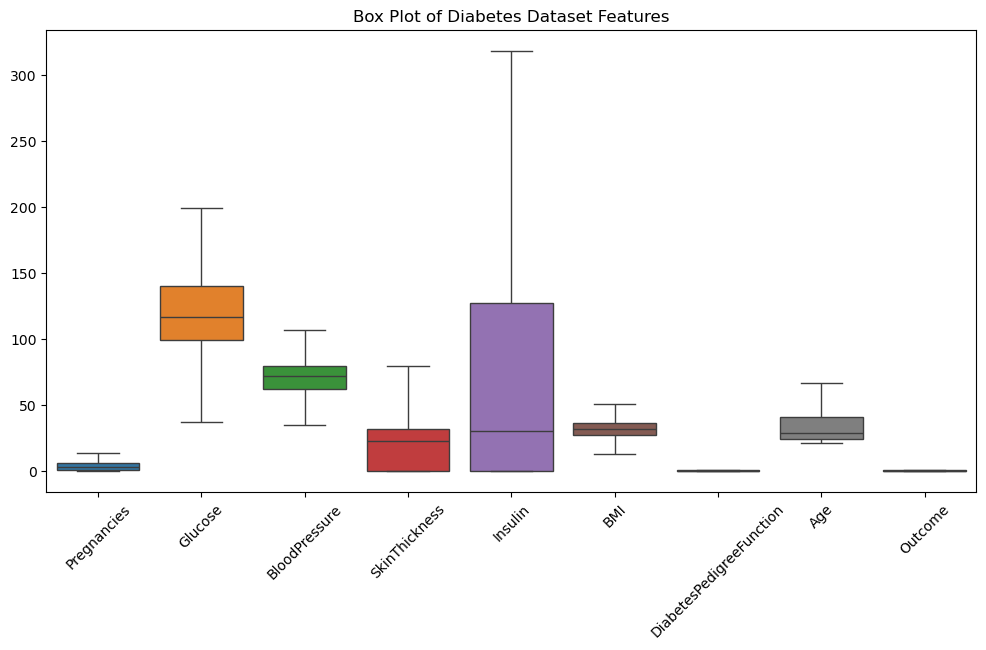

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title('Box Plot of Diabetes Dataset Features')
plt.show()

## 3. Exploring data distributions using histograms and box plots:
   
  ## Histogram :

    The histograms were used to study the distribution of numerical variables in the diabetes dataset. Features such as Glucose, BMI, and Age show how values are spread across the dataset. Some variables appear skewed, indicating that the data is not perfectly normally distributed.

  ## Box plot :

    Box plots were created to examine the spread of the data and identify possible outliers. Variables such as Insulin and SkinThickness contain extreme values that appear as outliers. Detecting outliers is important because they may influence machine learning model performance.


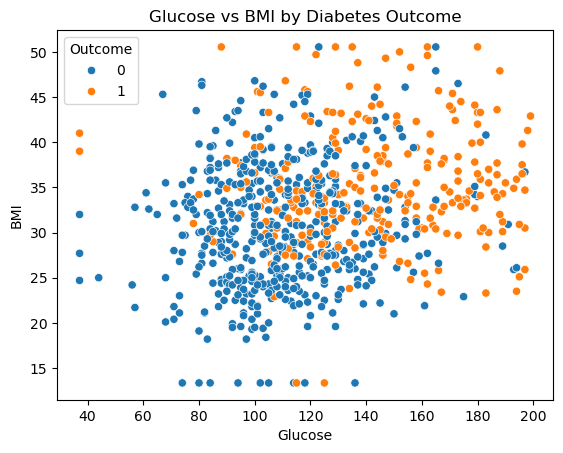

In [17]:
###4.Scatter PLots and Bar PLots:
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome')
plt.title('Glucose vs BMI by Diabetes Outcome')
plt.show()

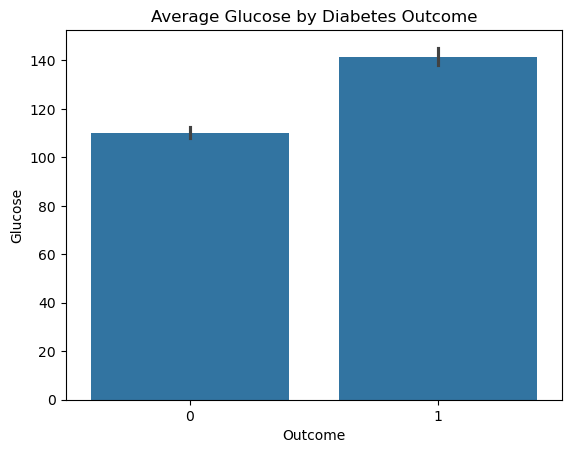

In [18]:
sns.barplot(data=df, x='Outcome', y='Glucose')
plt.title('Average Glucose by Diabetes Outcome')
plt.show()

## 4.Visualize relationships between features and survival using scatter plots and bar plots.
      
   ## Scatter plot:
            The scatter plot between Glucose and BMI shows the relationship between these two features with respect to the diabetes outcome. Individuals with higher glucose values tend to appear more frequently in the diabetic class, indicating that glucose may be an important predictor.

   ## Bar plot :
            The bar plot compares the average glucose level for each outcome category. The diabetic group generally has a higher average glucose level than the non-diabetic group, suggesting a positive association between glucose level and diabetes.

In [19]:
#####Data Preprocessing:
##1.Imputation  of missing values:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Explanation:
     Missing values were checked using isnull().sum(). All columns contained 0 missing values, so no imputation was required.

In [20]:
###2.Applying Encoding Techniques:
df.dtypes

Pregnancies                 float64
Glucose                     float64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

## Explanation:
    All features are numerical; therefore, no encoding was required.

In [21]:
###3.Additional preprocessing method:
from sklearn.preprocessing import StandardScaler

x = df.drop('Outcome', axis=1)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled[:5]

array([[ 0.64714967,  0.86192556,  0.09269135,  0.91498623, -0.787602  ,
         0.20935933,  0.58892732,  1.44569096],
       [-0.84896998, -1.15943299, -0.33020145,  0.536065  , -0.787602  ,
        -0.78425421, -0.37810147, -0.189304  ],
       [ 1.24559754,  1.98490253, -0.47116571, -1.29538762, -0.787602  ,
        -1.25267202,  0.74659506, -0.10325164],
       [-0.84896998, -1.03109276, -0.33020145,  0.15714377,  0.2175834 ,
        -0.57133702, -1.02278733, -1.04982767],
       [-1.14819391,  0.50898994, -2.16273688,  0.91498623,  1.00889957,
         1.55783484,  2.59656319, -0.01719927]])

## Explanation:
    Feature scaling was performed to standardize the input features.

In [22]:
######Building Predictive Models:
####1.Splitting the dataset into training and testing sets:
from sklearn.model_selection import train_test_split
# Features and target
x = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(x_train.shape, x_test.shape)

(614, 8) (154, 8)


 ## 1.Train–Test Split:

 ## Explanation:
         The dataset was divided into training and testing sets. The training set was used to train the model, and the testing set was used to evaluate model performance.

In [23]:
###2.Evaluation Metrics:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Explanation: 
     Accuracy, precision, recall, and F1-score were selected to measure classification performance. These metrics help evaluate overall accuracy and the model’s ability to identify diabetic cases correctly.

In [24]:
####3.Building the predictive models using LightGBM and XGBoost algorithms:
!pip install lightgbm xgboost

In [25]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(random_state=42)

In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

## 3.LightGBM and XGBoost Models:

## Explanation:
        LightGBM and XGBoost classification models were built using the preprocessed diabetes dataset. Both are boosting algorithms suitable for prediction tasks.

In [27]:
###4.Train and evaluate the models:
####LightGBM:
# Train
lgbm_model.fit(x_train, y_train)
# Predict
y_pred_lgbm = lgbm_model.predict(x_test)
# Evaluation
print('LightGBM Results')
print('Accuracy :', accuracy_score(y_test, y_pred_lgbm))
print('Precision:', precision_score(y_test, y_pred_lgbm))
print('Recall   :', recall_score(y_test, y_pred_lgbm))
print('F1-score :', f1_score(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 652
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [28]:
###XGBoost:
# Train
xgb_model.fit(x_train, y_train)
# Predict
y_pred_xgb = xgb_model.predict(x_test)
# Evaluation
print('XGBoost Results')
print('Accuracy :', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall   :', recall_score(y_test, y_pred_xgb))
print('F1-score :', f1_score(y_test, y_pred_xgb))

XGBoost Results
Accuracy : 0.7012987012987013
Precision: 0.5692307692307692
Recall   : 0.6727272727272727
F1-score : 0.6166666666666667


## 4.Model Training and Evaluation:
## Explanation:
        The models were trained on the training data and tested on the testing data. Performance metrics were calculated and compared for both models.

In [29]:
#####5.Cross-validation:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lgbm_model, x, y, cv=5, scoring='accuracy')
print('Cross-validation accuracy scores:', scores)
print('Mean accuracy:', scores.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [30]:
#### Hyperparameter tuning:
###LightGBM tuning:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best Accuracy  :', grid.best_score_)

[LightGBM] [Info] Number of positive: 142, number of negative: 267
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 504
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347188 -> initscore=-0.631422
[LightGBM] [Info] Start training from score -0.631422
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## 5.Cross-Validation and Hyperparameter Tuning:

## Explanation:
    Cross-validation was used to obtain reliable performance estimates, and hyperparameter tuning was applied to select the best model settings and improve accuracy

In [31]:
#####Comaparative Analysis:
##1.Comparing the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

      Model  Accuracy  Precision    Recall  F1-score
0  LightGBM  0.720779   0.590909  0.709091  0.644628
1   XGBoost  0.701299   0.569231  0.672727  0.616667


### Explanation:
  ## Comparing the performance metrics of LightGBM and XGBoost:

    The performance of LightGBM and XGBoost was compared using accuracy, precision, recall, and F1-score. The model with higher metric values showed better prediction performance on the diabetes dataset. This comparison helped identify the more effective algorithm for diabetes classification.


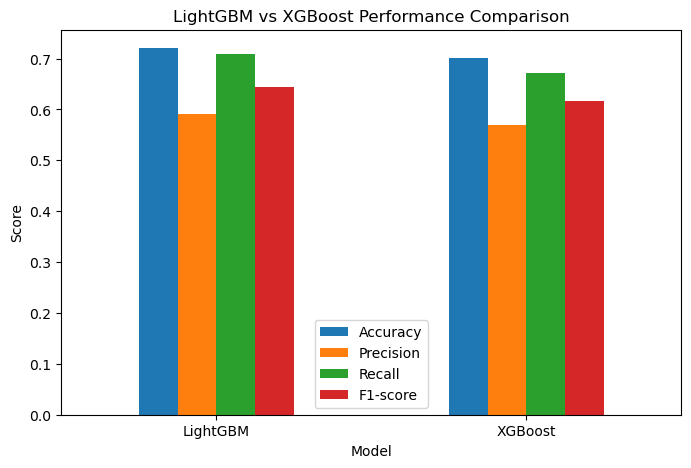

In [32]:
##2.Visualizing the results:
import matplotlib.pyplot as plt
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.ylabel('Score')
plt.title('LightGBM vs XGBoost Performance Comparison')
plt.xticks(rotation=0)
plt.show()

## Explanation:
        
        The bar chart visually compares the performance metrics of both models, making it easy to identify the better-performing algorithm.
  ## Interpretation :
  
   ## Comparative Interpretation:

      The model with the higher accuracy provides better overall prediction performance.
      The model with the higher precision produces fewer false positive predictions.
      The model with the higher recall identifies more diabetic patients correctly.
      The model with the higher F1-score shows a better balance between precision and recall.

## Strengths and Weaknesses:

   ## LightGBM:

        Faster training and lower memory usage.
        Performs well on large datasets.
        May be slightly less accurate on some datasets.

   ## XGBoost:
        Often provides better prediction accuracy.
        Handles complex patterns effectively.
        Training can be slower and more computationally intensive.
## Conclusion:
            The performance metrics were visualized using a bar chart to compare LightGBM and XGBoost. The model with higher metric values showed better predictive performance. LightGBM trained faster and used less memory, while XGBoost generally provided slightly better accuracy and overall prediction performance.